# Signal separation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os, wget
import pyedflib  # to read EDF files

import neurokit2 as nk  # for ECG preprocessing and segmentation

from scipy.linalg import svd, hankel
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.cluster import KMeans
from collections import defaultdict
from ecg_svd.config import FIGURES_DIR

2025-09-15 16:16:18.582 | INFO     | ecg_svd.config:<module>:11 - PROJ_ROOT path is: C:\Users\Ester\Desktop\ecg-svd


In [2]:
# # Run this cell only if you need to download the dataset
# !cd .. && mkdir data\raw && cd data\raw
# !python -m wget https://physionet.org/files/adfecgdb/1.0.0/r01.edf -o ../data/raw/r01.edf
# !python -m wget https://physionet.org/files/adfecgdb/1.0.0/r01.edf -o ../data/raw/r04.edf
# !python -m wget https://physionet.org/files/adfecgdb/1.0.0/r01.edf -o ../data/raw/r07.edf
# !python -m wget https://physionet.org/files/adfecgdb/1.0.0/r01.edf -o ../data/raw/r08.edf
# !python -m wget https://physionet.org/files/adfecgdb/1.0.0/r01.edf -o ../data/raw/r10.edf

In [106]:
# Step 1: Embedding

# Step 2: SVD

# Step 3: Grouping/Clustering
def reconstruct_component(U, s, Vh, indices):
    component = sum(s[i] * np.outer(U[:, i], Vh[i, :]) for i in indices)
    return component

# Step 4: Diagonal averaging (Hankelization)
def diagonal_averaging(X):
    L, K = X.shape
    N = L + K - 1
    reconstructed = np.zeros(N)
    counts = np.zeros(N)

    for i in range(L):
        for j in range(K):
            reconstructed[i + j] += X[i, j]
            counts[i + j] += 1

    return reconstructed / counts

In [6]:
edf_file = "r01.edf"
edf_path = os.path.join("..", "data", "raw", edf_file)
plot_fig_path = os.path.join("..", "reports", "figures", "4-signal-separation")

In [7]:
# Load EDF file
edf = pyedflib.EdfReader(edf_path)

In [107]:
def get_signal_segment(channel_number, duration_seconds=5):
    sampling_rate = edf.getSampleFrequency(channel_number)
    signal = edf.readSignal(channel_number)
    onsets, _, _ = edf.readAnnotations()
    
    start_time = max(0, onsets[0] - duration_seconds)
    end_time = onsets[0] + duration_seconds
    
    start_sample = int(start_time * sampling_rate)
    end_sample = int(end_time * sampling_rate)
    
    signal_segment = signal[start_sample:end_sample]
    time_segment = np.linspace(start_time, end_time, len(signal_segment))
    
    onsets_in_segment = onsets[(onsets >= start_time) & (onsets <= end_time)]
    onset_values = np.interp(onsets_in_segment, time_segment, signal_segment)
    
    return signal_segment, time_segment, onsets_in_segment, onset_values

def plot_signal_with_onsets(signal, time, onsets, onset_values, title, filename=None):
    plt.figure(figsize=(15, 5))
    
    plt.plot(time, signal, label='Signal')
    plt.plot(onsets, onset_values, 'ro', markersize=8, label="Fetal Peaks")
    plt.xlabel('Time (seconds)')
    plt.ylabel('Amplitude (mV)')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    if filename:
        plt.savefig(plot_fig_path / filename)
    plt.show()

In [108]:
direct_segment, time_segment, onsets, values = get_signal_segment(0)
abdomen_segment_1, time_segment_1, onsets_1, values_1 = get_signal_segment(1)
abdomen_segment_2, time_segment_2, onsets_2, values_2 = get_signal_segment(2)
abdomen_segment_3, time_segment_3, onsets_3, values_3 = get_signal_segment(3)
abdomen_segment_4, time_segment_4, onsets_4, values_4 = get_signal_segment(4)

# plot_signal_with_onsets(direct_segment, time_segment, onsets, values, title="Fetal Signal with Onsets")
# plot_signal_with_onsets(abdomen_segment_1, time_segment_1, onsets_1, values_1, title="Abdominal Signal 1 with Onsets")
# plot_signal_with_onsets(abdomen_segment_2, time_segment_2, onsets_2, values_2, title="Abdominal Signal 2 with Onsets")
# plot_signal_with_onsets(abdomen_segment_3, time_segment_3, onsets_3, values_3, title="Abdominal Signal 3 with Onsets")
# plot_signal_with_onsets(abdomen_segment_4, time_segment_4, onsets_4, values_4, title="Abdominal Signal 4 with Onsets")

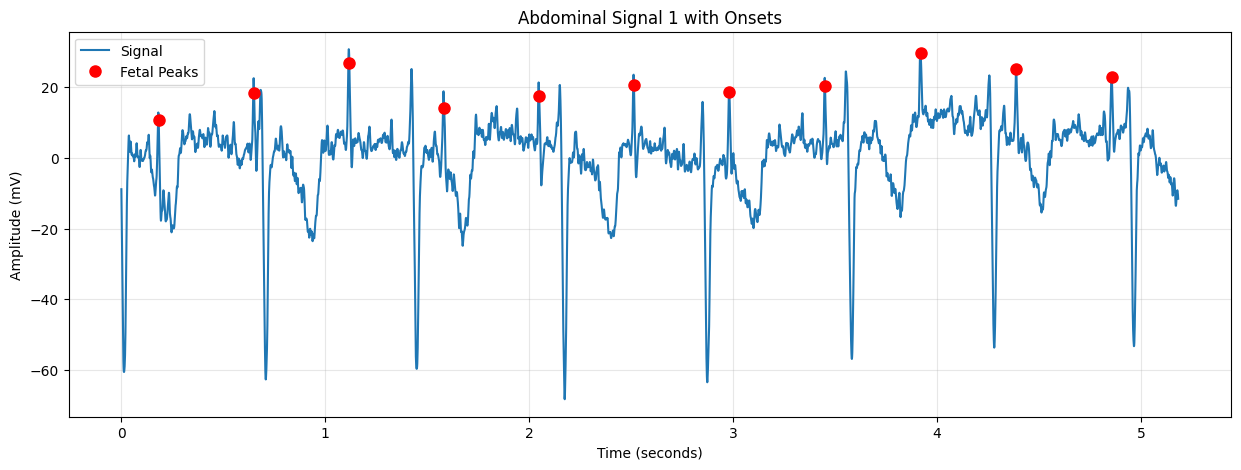

In [109]:
plot_signal_with_onsets(abdomen_segment_1, time_segment_1, onsets_1, values_1, title="Abdominal Signal 1 with Onsets")


In [110]:
# Create hankel matrix of each segment
L = 637 * 2  # window length
# L = 150
H_abdomen_1 = hankel(abdomen_segment_1[:L], abdomen_segment_1[L-1:])
H_abdomen_2 = hankel(abdomen_segment_2[:L], abdomen_segment_2[L-1:])
H_abdomen_3 = hankel(abdomen_segment_3[:L], abdomen_segment_3[L-1:])
H_abdomen_4 = hankel(abdomen_segment_4[:L], abdomen_segment_4[L-1:])

In [11]:
import numpy as np
import tensorly as tl
from tensorly.decomposition import parafac
import matplotlib.pyplot as plt

# Build tensor (L, K, M)
tensor = np.stack([H_abdomen_1, H_abdomen_2, H_abdomen_3, H_abdomen_4], axis=2)
tensor = tl.tensor(tensor)

# Decomposition
R = 3
decomp = parafac(tensor, rank=R)

# Extract weights and factor matrices
weights, factors = decomp
A, B, C = factors   # A: (L x R), B: (K x R), C: (M x R)


In [ ]:
decomp, errors = parafac(tensor, rank=4, return_errors=True)

MemoryError: Unable to allocate 412. TiB for an array with shape (7529340, 7529340) and data type float64

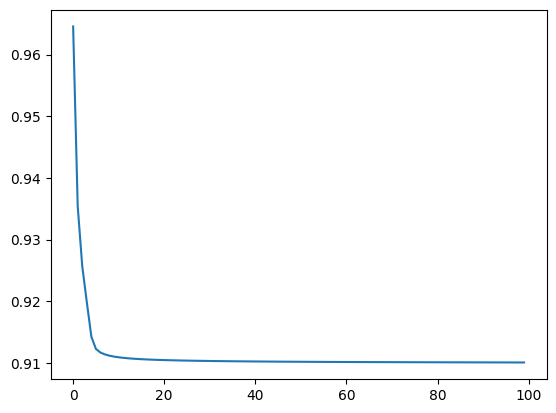

In [17]:
plt.plot(errors)

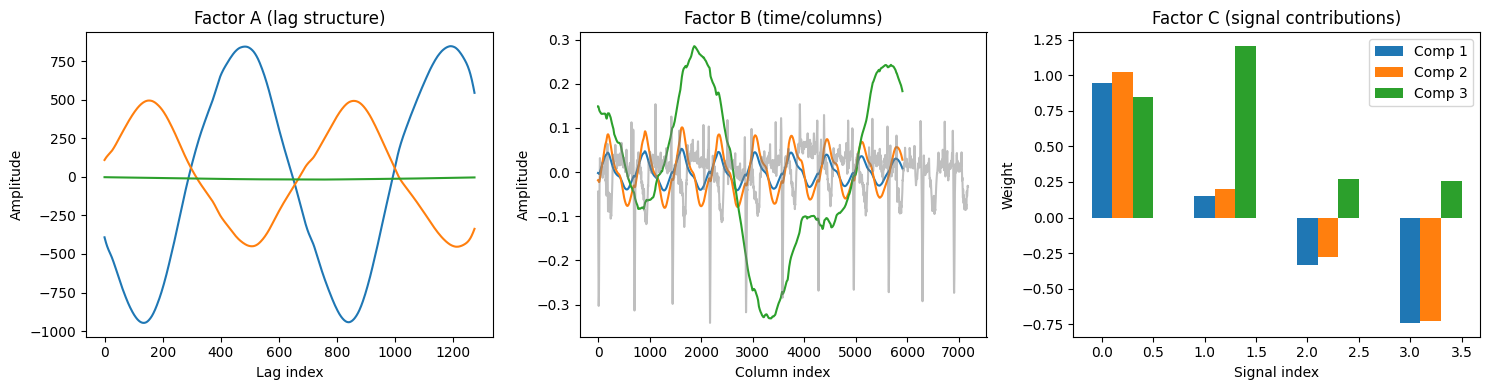

In [16]:
# ---- Plot the factors ----
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# A: lag / window structure
axes[0].plot(A)

axes[0].set_title('Factor A (lag structure)')
axes[0].set_xlabel('Lag index')
axes[0].set_ylabel('Amplitude')

# B: temporal evolution (across Hankel columns)
axes[1].plot(B)
axes[1].plot(abdomen_segment_1 / 60 * 0.3, color='gray', alpha=0.5)
axes[1].set_title('Factor B (time/columns)')
axes[1].set_xlabel('Column index')
axes[1].set_ylabel('Amplitude')

# C: loadings per signal
for r in range(R):
    axes[2].bar(np.arange(C.shape[0]) + r*0.2, C[:, r], width=0.2, label=f'Comp {r+1}')
axes[2].set_title('Factor C (signal contributions)')
axes[2].set_xlabel('Signal index')
axes[2].set_ylabel('Weight')
axes[2].legend()

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

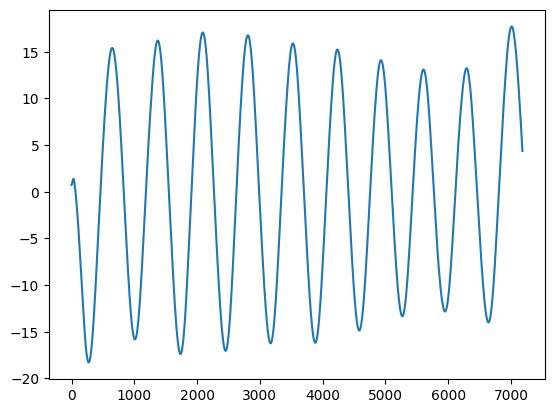

In [27]:
AB0 = np.outer(A[:, 0], B[:, 0]) * C[0, 0]
AB1 = np.outer(A[:, 1], B[:, 1]) * C[0, 1]
AB2 = np.outer(A[:, 2], B[:, 2]) * C[0, 2]
plt.plot(diagonal_averaging(AB0))
plt.plot(diagonal_averaging(AB1))
plt.plot(diagonal_averaging(AB2))
plt.legend(['Comp 1', 'Comp 2', 'Comp 3'])

In [111]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd, hankel
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, OPTICS, MeanShift, SpectralClustering
from sklearn.mixture import GaussianMixture

def reconstruct_component(U, s, Vh, indices):
    Hc = np.sum([s[i] * np.outer(U[:, i], Vh[i, :]) for i in indices], axis=0)
    return Hc

def diagonal_averaging(H):
    L, K = H.shape
    N = L + K - 1
    y = np.zeros(N)
    counts = np.zeros(N)
    for i in range(L):
        for j in range(K):
            y[i+j] += H[i,j]
            counts[i+j] += 1
    return y / counts

def reconstruct_clusters(labels, U, s, Vh):
    reconstructed = []
    for c in np.unique(labels):
        if c == -1:  # skip DBSCAN noise
            continue
        indices = np.where(labels==c)[0]
        Hc = reconstruct_component(U, s, Vh, indices)
        reconstructed.append(diagonal_averaging(Hc))
    return reconstructed

rank = 15
L = 150
signal = abdomen_segment_1  # 1D segment
H = hankel(signal[:L], signal[L-1:])

U, s, Vh = svd(H, full_matrices=False)
singular_values = s[:rank].reshape(-1,1)

cluster_algos = {
    'KMeans': KMeans(n_clusters=3, random_state=0),
    'GMM': GaussianMixture(n_components=3, random_state=0),
    'Agglomerative': AgglomerativeClustering(n_clusters=3),
    'DBSCAN': DBSCAN(eps=0.3, min_samples=1),
    'MeanShift': MeanShift(),
    'Spectral': SpectralClustering(n_clusters=3, affinity='nearest_neighbors', assign_labels='kmeans', random_state=0)
}

reconstructed_signals = {}

for name, algo in cluster_algos.items():
    if name == 'GMM':
        labels = algo.fit_predict(singular_values)
    else:
        labels = algo.fit_predict(singular_values)
    reconstructed_signals[name] = reconstruct_clusters(labels, U, s, Vh)

plt.figure(figsize=(15, 14))
for i, (name, signals) in enumerate(reconstructed_signals.items()):
    plt.subplot(len(reconstructed_signals), 1, i+1)
    for s in signals:
        plt.plot(s)
    plt.title(f'{name} clusters')
plt.tight_layout()
plt.show()


KeyboardInterrupt: 

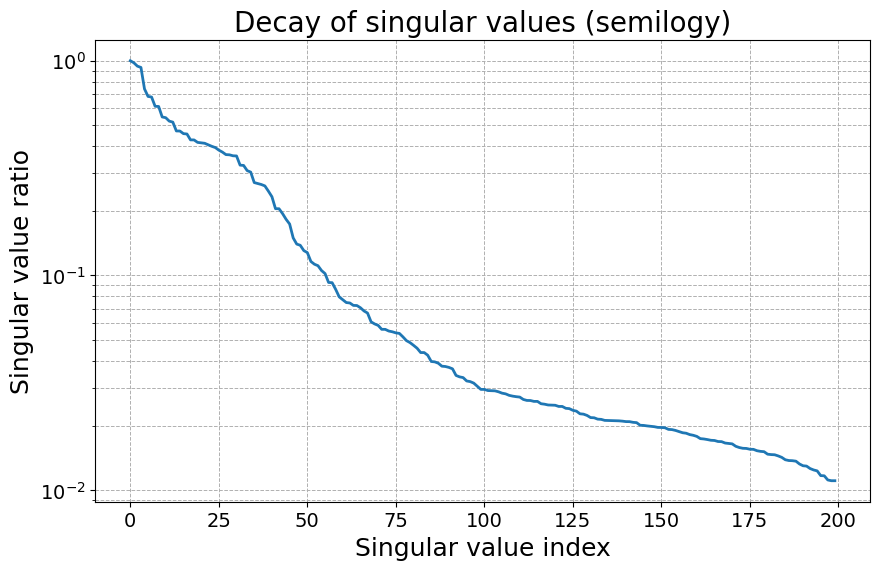

In [141]:
from scipy.linalg import hankel, svd
import matplotlib.ticker as ticker

L = 700
H = hankel(abdomen_segment_1[:L], abdomen_segment_1[L-1:])
U, s, Vh = svd(H, full_matrices=False)
plt.figure(figsize=(10,6))
ratio = s / s[0]
plt.semilogy(ratio[0:200])
plt.xlabel("Singular value index")
plt.ylabel("Singular value ratio")
plt.title("Decay of singular values (semilogy)")
plt.grid(True, which="both", linestyle="--", linewidth=0.7)
plt.show()

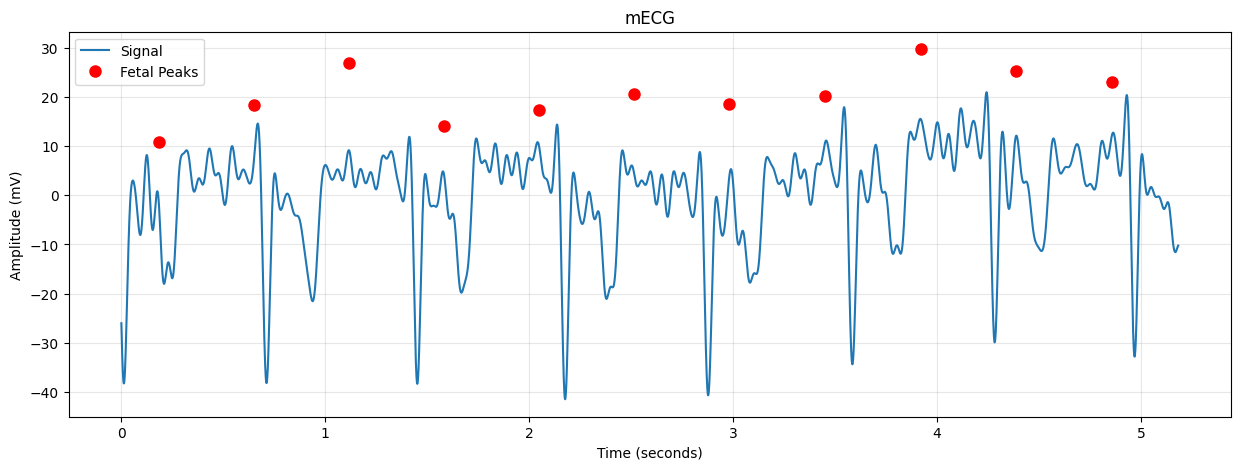

In [112]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import hankel, svd

def plot_hankel_components(signal, L, start_idx, end_idx, title="Hankel Components"):
    """
    Perform Hankelization, SVD, reconstruct selected components, and plot.

    Parameters:
        signal : 1D array, the original abdominal signal
        L : int, Hankel window length
        start_idx : int, starting singular value index (inclusive)
        end_idx : int, ending singular value index (inclusive)
        title : str, title for the plots
    """
    # 1. Hankelization
    H = hankel(signal[:L], signal[L-1:])

    # 2. SVD
    U, s, Vh = svd(H, full_matrices=False)

    # 3. Reconstruct the selected components
    indices = list(range(start_idx, end_idx + 1))
    Hc = np.sum([s[i] * np.outer(U[:, i], Vh[i, :]) for i in indices], axis=0)

    # 4. Diagonal averaging to get time-domain signal
    Lh, K = Hc.shape
    N = Lh + K - 1
    reconstructed_signal = np.zeros(N)
    counts = np.zeros(N)
    for i in range(Lh):
        for j in range(K):
            reconstructed_signal[i+j] += Hc[i,j]
            counts[i+j] += 1
    reconstructed_signal /= counts
    
    # # 5. Plot the original signal with light color and reconstructed signal
    # plt.figure(figsize=(12,5))
    # plt.plot(signal[:N], color='lightgray', label='Original Signal')
    # plt.plot(reconstructed_signal, color='red', linewidth=2, label='Reconstructed Signal')
    # plt.title(f"{title} - Singular Values {start_idx}-{end_idx}")
    # plt.xlabel('Samples')
    # plt.ylabel('Amplitude')
    # plt.legend()
    # plt.grid(True, alpha=0.3)
    # plt.show()

    return reconstructed_signal, Hc

# Reconstruct singular values 0 to 4 with window length 150
mecg, H_matrix = plot_hankel_components(
    signal=abdomen_segment_1, 
    L=700, 
    start_idx=0, 
    end_idx=20, 
    title="Selected Components"
)

plot_signal_with_onsets(mecg, time_segment_1, onsets_1, values_1, title="mECG")

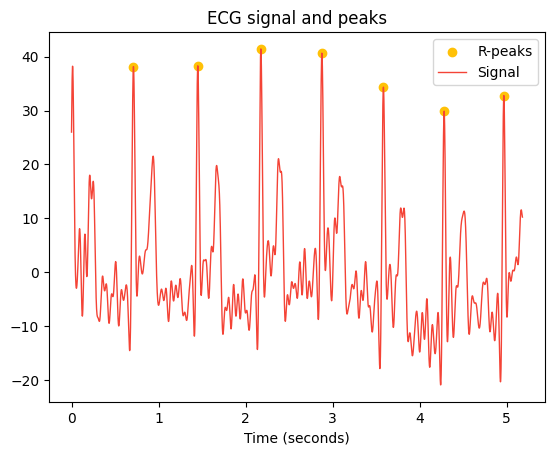

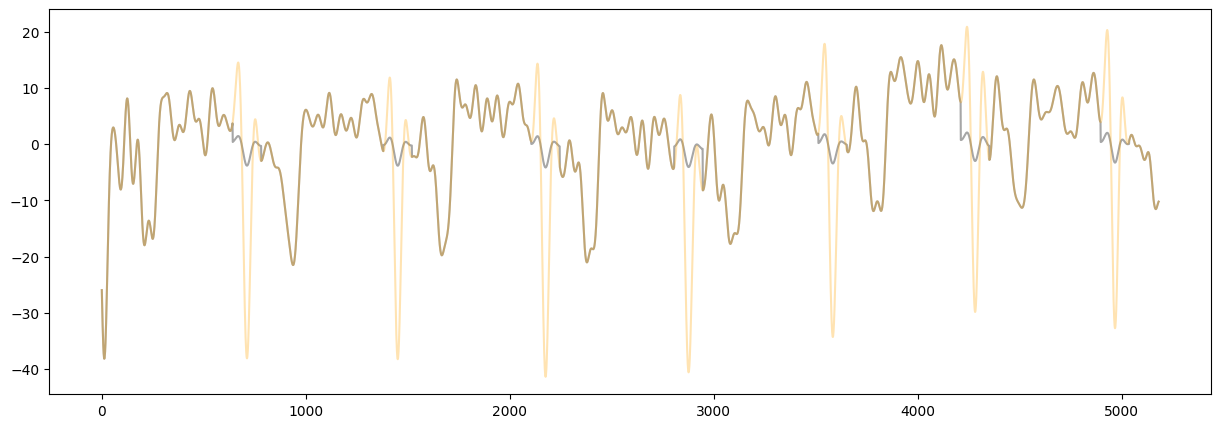

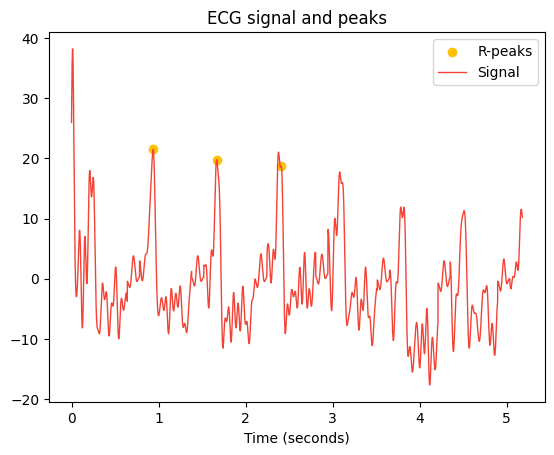

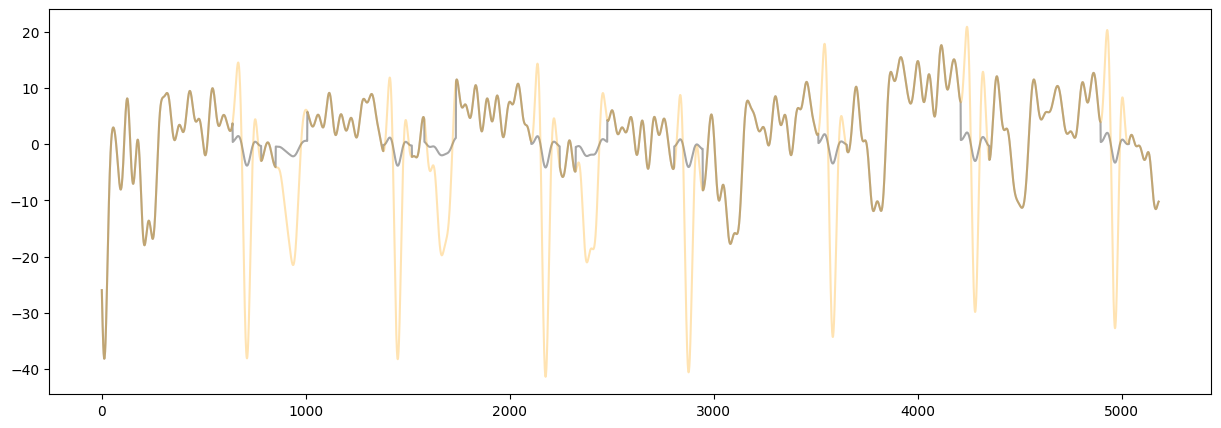

In [113]:
# mecg_copy = mecg.copy()
# mecg_copy[info['ECG_R_Peaks']] = 0
# plt.plot(mecg_copy)
signals, info1 = nk.ecg_peaks(-mecg, sampling_rate=1000, correct_artifacts=True, show=True)
mecg_copy1 = mecg.copy()
for i in range(len(info1['ECG_R_Peaks'])):
    mecg_copy1[info1['ECG_R_Peaks'][i]-70:info1['ECG_R_Peaks'][i]+70] = mecg[info1['ECG_R_Peaks'][i]-70:info1['ECG_R_Peaks'][i]+70] * 0.1
plt.figure(figsize=(15, 5))
plt.plot(mecg_copy1, color='grey', alpha=0.7)
plt.plot(mecg, color='orange', alpha=0.3)

mecg_copy2 = mecg_copy1.copy()
signals, info2 = nk.ecg_peaks(-mecg_copy2, sampling_rate=1000, correct_artifacts=True, show=True)
for i in range(len(info2['ECG_R_Peaks'])):
    mecg_copy2[info2['ECG_R_Peaks'][i]-85:info2['ECG_R_Peaks'][i]+70] = mecg[info2['ECG_R_Peaks'][i]-85:info2['ECG_R_Peaks'][i]+70] * 0.1
plt.figure(figsize=(15, 5))
plt.plot(mecg_copy2, color='grey', alpha=0.7)
plt.plot(mecg, color='orange', alpha=0.3)


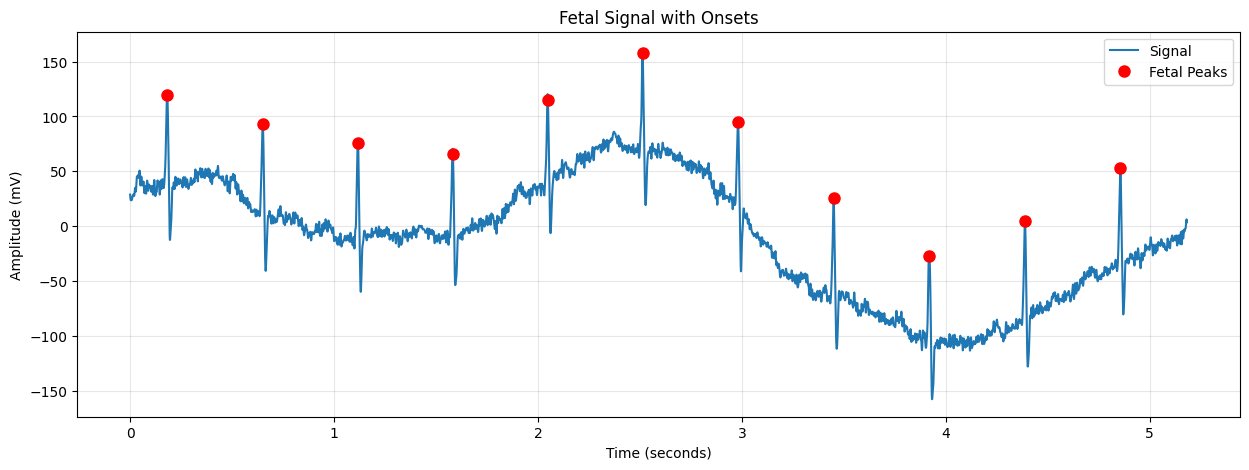

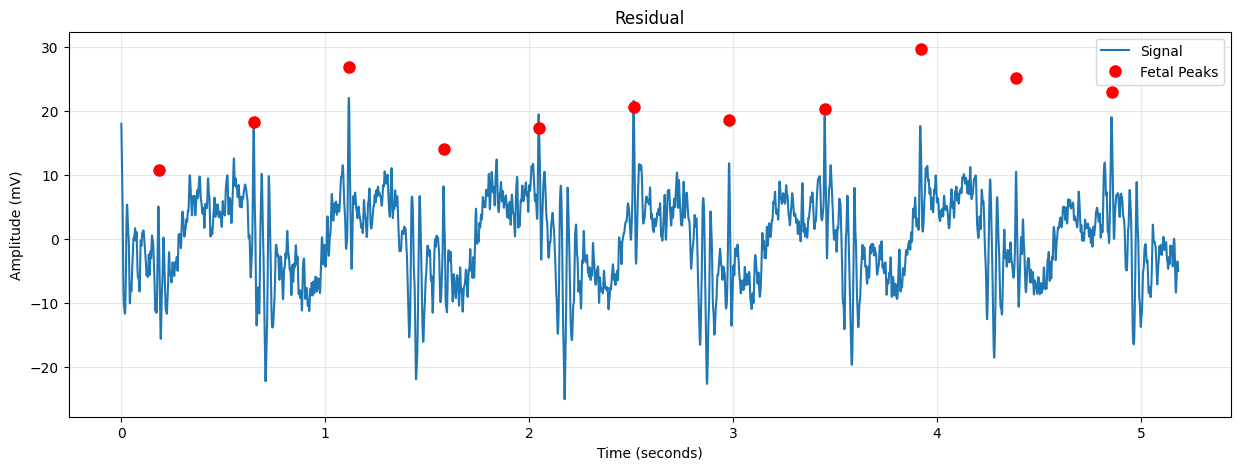

In [114]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import hankel, svd

def diagonal_averaging(H):
    """Reconstruct a 1D signal from a Hankel matrix by diagonal averaging."""
    L, K = H.shape
    N = L + K - 1
    x_reconstructed = np.zeros(N)
    counts = np.zeros(N)
    
    for i in range(L):
        for j in range(K):
            x_reconstructed[i+j] += H[i, j]
            counts[i+j] += 1
    return x_reconstructed / counts

L = 700
start_idx, end_idx = 3, 30

H = hankel(abdomen_segment_1[:L], abdomen_segment_1[L-1:])
U, s, Vh = svd(H, full_matrices=False)

H_maternal = np.zeros_like(H)
for i in range(start_idx, end_idx+1):
    H_maternal += s[i] * np.outer(U[:, i], Vh[i, :])

mECG = diagonal_averaging(H_maternal)
residual = abdomen_segment_1[:len(mECG)] - mECG

plot_signal_with_onsets(direct_segment, time_segment, onsets, values, title="Fetal Signal with Onsets")
plot_signal_with_onsets(residual, time_segment_1, onsets_1, values_1, title="Residual")


<Figure size 1500x500 with 0 Axes>

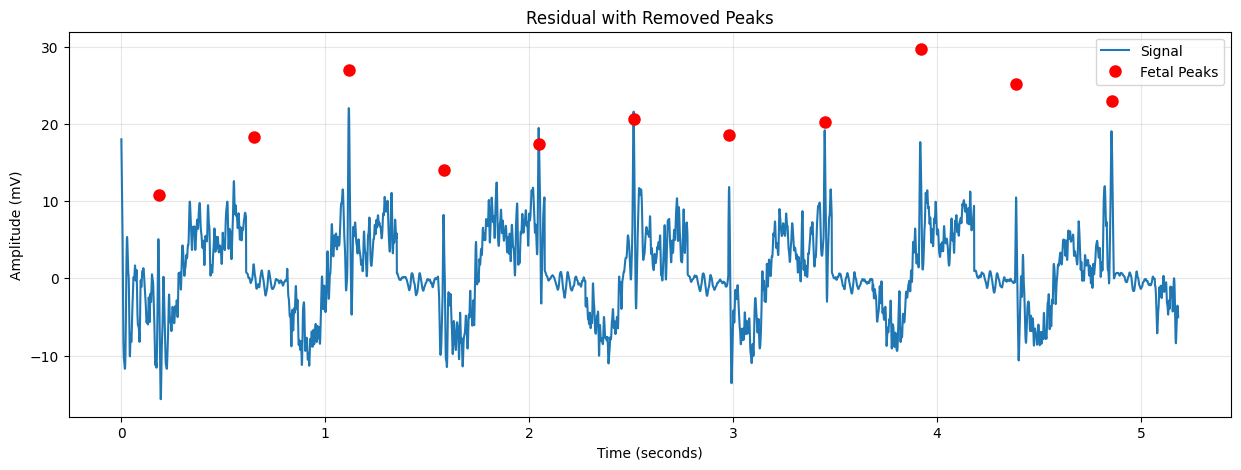

In [115]:
fecg_copy = residual.copy()
for i in range(len(info1['ECG_R_Peaks'])):
    fecg_copy[info1['ECG_R_Peaks'][i]-100:info1['ECG_R_Peaks'][i]+100] = fecg_copy[info1['ECG_R_Peaks'][i]-100:info1['ECG_R_Peaks'][i]+100] * 0.1
# for i in range(len(info2['ECG_R_Peaks'])):
#     fecg_copy[info2['ECG_R_Peaks'][i]-100:info2['ECG_R_Peaks'][i]+100] = fecg_copy[info2['ECG_R_Peaks'][i]-100:info2['ECG_R_Peaks'][i]+100] * 0.1
plt.figure(figsize=(15, 5))
plot_signal_with_onsets(fecg_copy, time_segment_1, onsets_1, values_1, title="Residual with Removed Peaks")

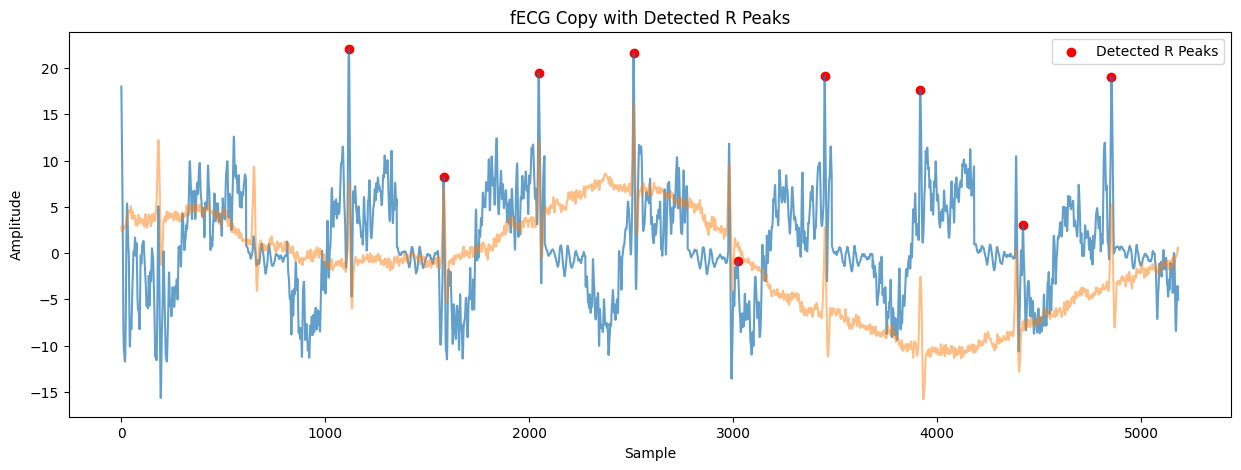

In [116]:
signals, info = nk.ecg_peaks(fecg_copy, sampling_rate=1000, correct_artifacts=False, show=False)
plt.figure(figsize=(15, 5))
plt.plot(fecg_copy, alpha=0.7)
plt.scatter(info['ECG_R_Peaks'], fecg_copy[info['ECG_R_Peaks']], color='red', label='Detected R Peaks')
plt.plot(direct_segment*0.1, alpha=0.5)
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.title('fECG Copy with Detected R Peaks')
plt.legend()
plt.show()

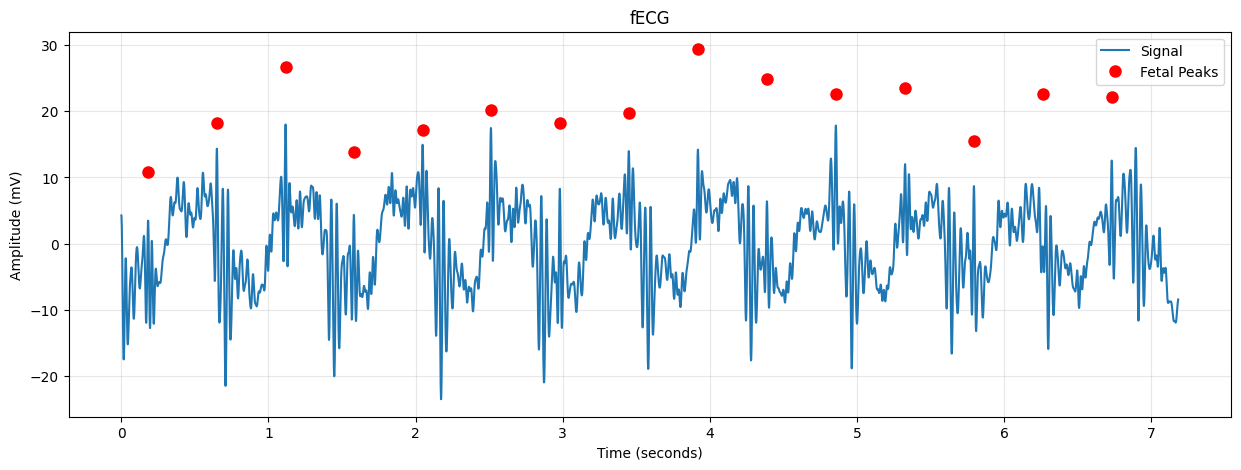

In [104]:
fecg, res = plot_hankel_components(
    signal=residual, 
    L=400, 
    start_idx=0, 
    end_idx=28, 
    title="Selected Components"
)

plot_signal_with_onsets(fecg, time_segment_1, onsets_1, values_1, title="fECG")


In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import hankel, svd
from sklearn.cluster import KMeans

L = 700
n_components = 3
signals = [abdomen_segment_1, abdomen_segment_2, abdomen_segment_3, abdomen_segment_4]

H_list = []
for sig in signals:
    H = hankel(sig[:L], sig[L-1:])  # shape (L, K)
    H_list.append(H)
H_multi = np.concatenate(H_list, axis=0)  # shape (4*L, K)

U, s, Vh = svd(H_multi, full_matrices=False)

singular_values = s.reshape(-1,1)
kmeans = KMeans(n_clusters=n_components, random_state=42)
labels = kmeans.fit_predict(singular_values)

def diagonal_averaging(H_comp):
    L, K = H_comp.shape
    N = L + K - 1
    x = np.zeros(N)
    counts = np.zeros(N)
    for i in range(L):
        for j in range(K):
            x[i+j] += H_comp[i,j]
            counts[i+j] += 1
    return x / counts

components = []
for c in range(n_components):
    H_c = np.zeros_like(H_multi)
    for i, lbl in enumerate(labels):
        if lbl == c:
            H_c += s[i] * np.outer(U[:,i], Vh[i,:])
    comp_signal = diagonal_averaging(H_c)
    components.append(comp_signal)


KeyboardInterrupt: 

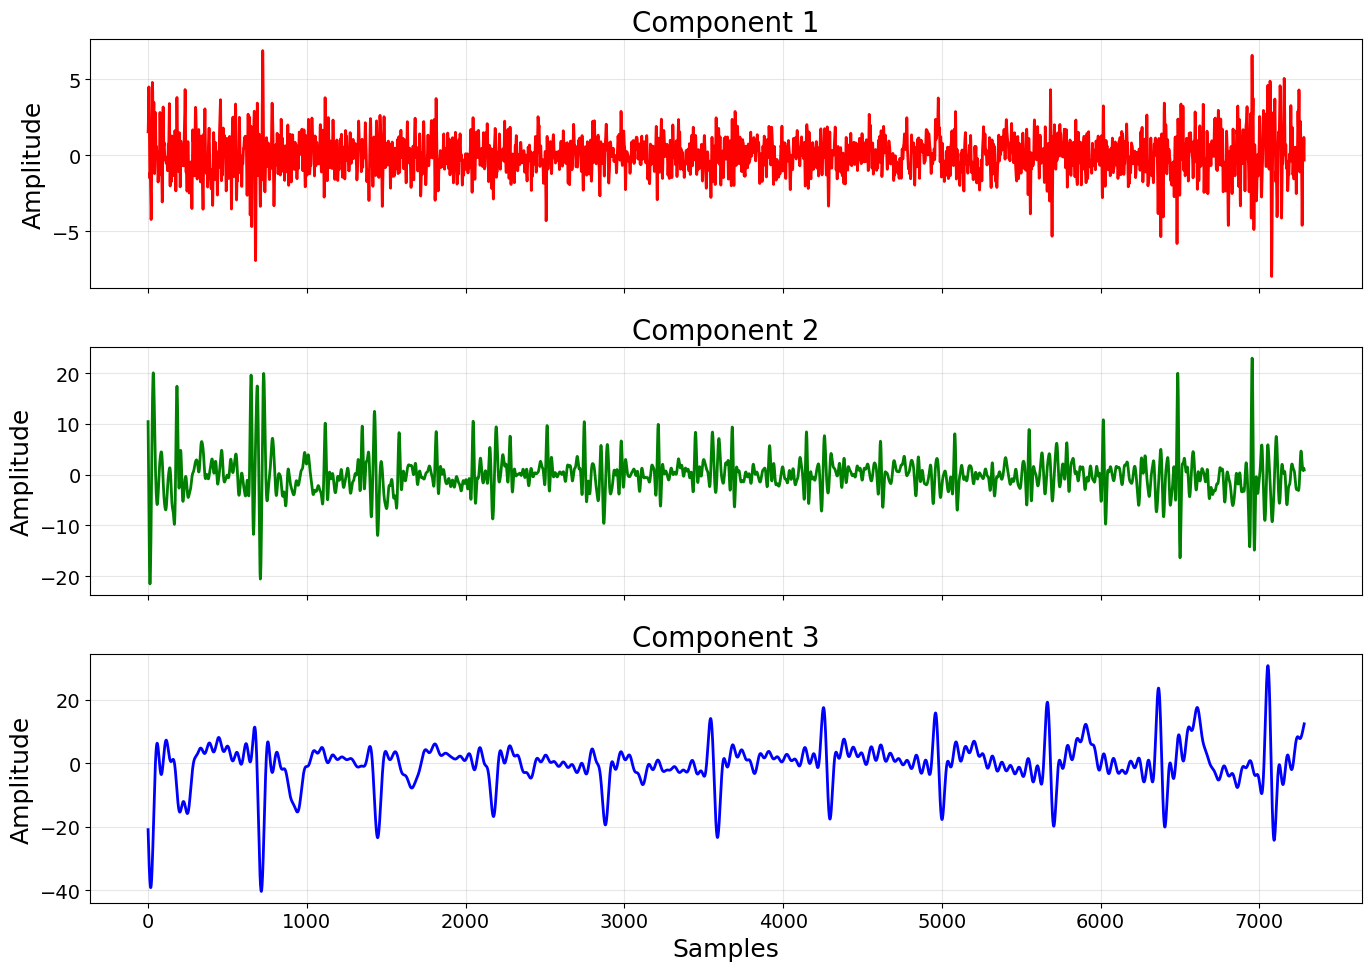

In [ ]:
import matplotlib.pyplot as plt

colors = ['red', 'green', 'blue']
titles = ['Component 1', 'Component 2', 'Component 3']

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i, ax in enumerate(axes):
    ax.plot(components[i], color=colors[i])
    ax.set_ylabel("Amplitude")
    ax.set_title(titles[i])
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Samples")
plt.tight_layout()
plt.show()


## Old experiments

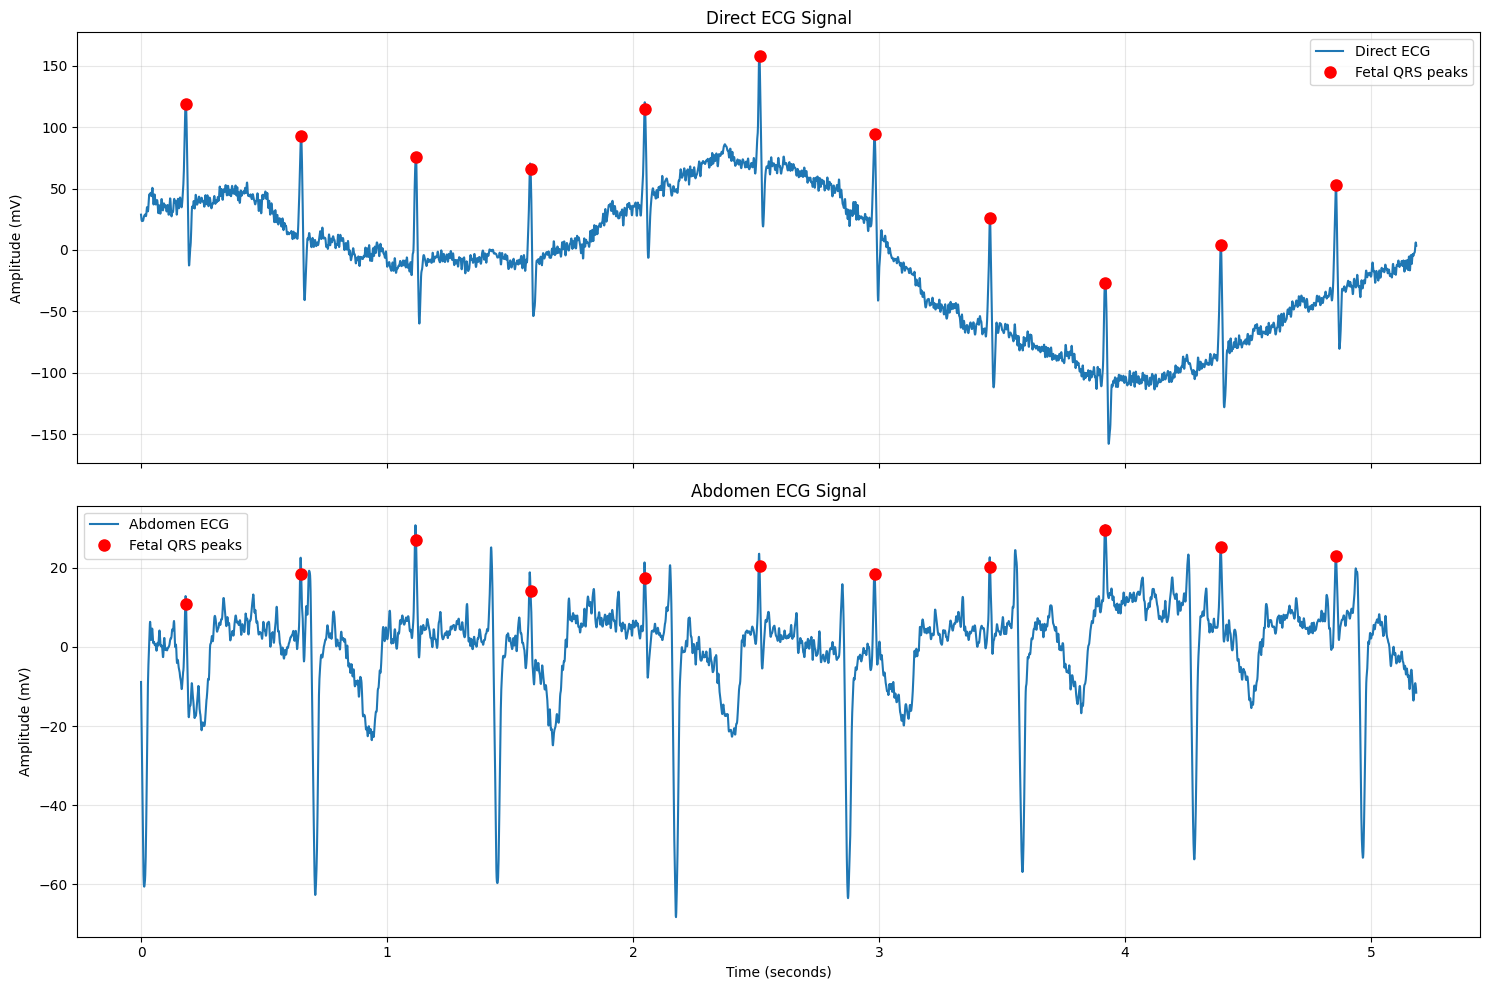

In [13]:
sampling_rate = edf.getSampleFrequency(0)

direct_signal = edf.readSignal(0) # 0 = Direct
abdomen_signal = edf.readSignal(1) # 1 = Abdomen_1, 2 = Abdomen_2, 3 = Abdomen_3, 4 = Abdomen_4
onsets, durations, labels = edf.readAnnotations()

first_onset = onsets[0]
first_label = labels[0]
window_duration = 5.0 # Let's use a bigger window (e.g. 5 or 7 seconds)
start_time = max(0, first_onset - window_duration)
end_time = first_onset + window_duration

# Convert to sample indices
start_sample = int(start_time * sampling_rate)
end_sample = int(end_time * sampling_rate)

# Extract the signal segment
direct_signal_segment = direct_signal[start_sample:end_sample]
abdomen_signal_segment = abdomen_signal[start_sample:end_sample]
direct_time_segment = np.linspace(start_time, end_time, len(direct_signal_segment))
abdomen_time_segment = np.linspace(start_time, end_time, len(abdomen_signal_segment)) # This should be the same as direct_time_segment

# Get the onsets within the specified time window and interpolate their values
onsets_in_window = onsets[(onsets >= start_time) & (onsets <= end_time)]
direct_onset_values = np.interp(onsets_in_window, direct_time_segment, direct_signal_segment)
abdomen_onset_values = np.interp(onsets_in_window, abdomen_time_segment, abdomen_signal_segment) # This should be the same as direct_onset_values

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Direct signal
ax1.plot(direct_time_segment, direct_signal_segment, label='Direct ECG')
ax1.plot(onsets_in_window, direct_onset_values, 'ro', markersize=8, label="Fetal QRS peaks")
ax1.set_ylabel('Amplitude (mV)')
ax1.set_title(f'Direct ECG Signal')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Abdomen signal
ax2.plot(abdomen_time_segment, abdomen_signal_segment, label='Abdomen ECG')
ax2.plot(onsets_in_window, abdomen_onset_values, 'ro', markersize=8, label="Fetal QRS peaks")
ax2.set_xlabel('Time (seconds)')
ax2.set_ylabel('Amplitude (mV)')
ax2.set_title(f'Abdomen ECG Signal')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

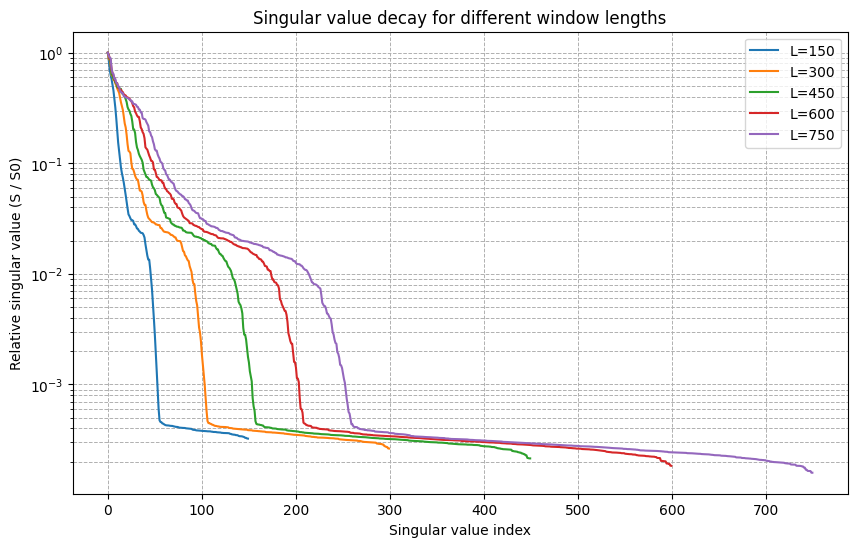

In [14]:
# in this experiment, we will try different window lengths
# for now, we will test with values that can perfectly divide the signal length
L_values = [150, 300, 450, 600, 750]

plt.figure(figsize=(10,6))

for L in L_values:
    X = embed(abdomen_signal_segment, L)
    U, S, Vt = np.linalg.svd(X, full_matrices=False)
    ratio = S / S[0]
    plt.semilogy(ratio, label=f"L={L}")

plt.xlabel("Singular value index")
plt.ylabel("Relative singular value (S / S0)")
plt.title("Singular value decay for different window lengths")
plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.7)
plt.show()


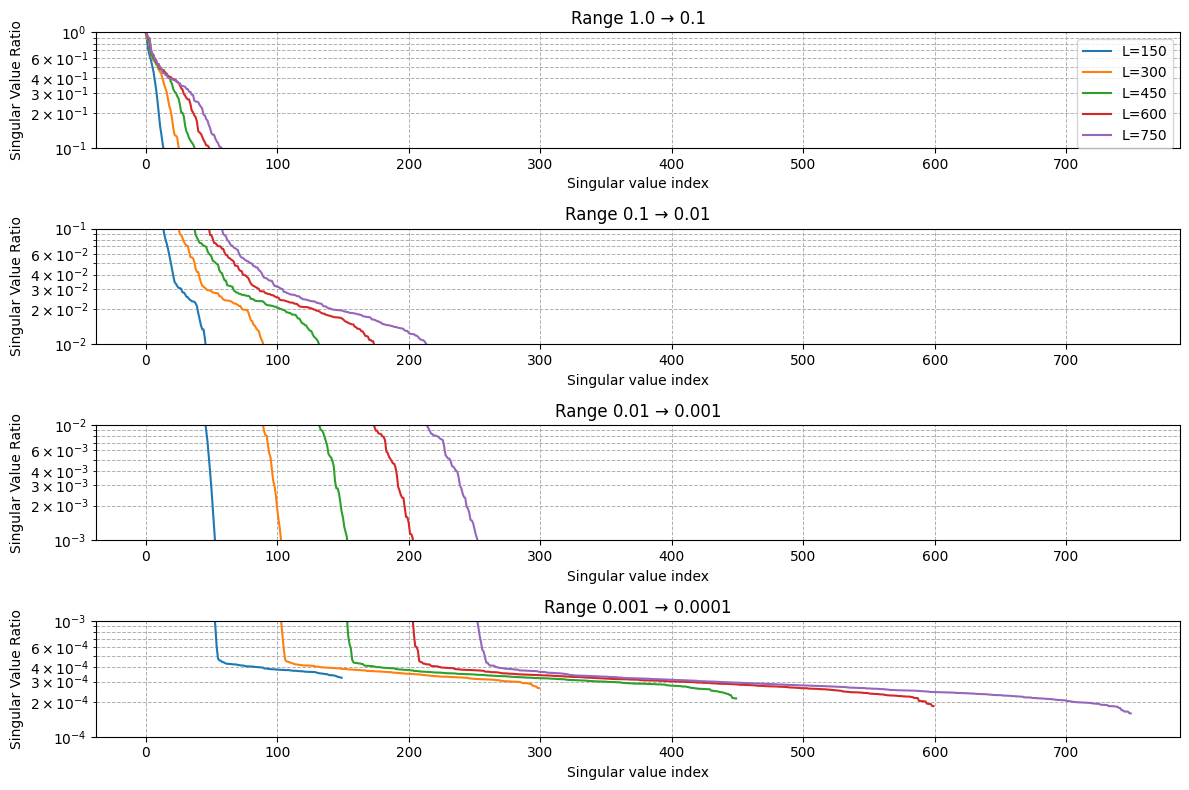

In [15]:
import numpy as np
import matplotlib.pyplot as plt

L_values = [150, 300, 450, 600, 750]

# Define y-axis ranges (log scale)
ranges = [(1e0, 1e-1), (1e-1, 1e-2), (1e-2, 1e-3), (1e-3, 1e-4)]

fig, axes = plt.subplots(4, 1, figsize=(12,8))
axes = axes.flatten()

for ax, (ymax, ymin) in zip(axes, ranges):
    for L in L_values:
        # Build trajectory matrix
        X = embed(abdomen_signal_segment, L)

        # Perform SVD
        U, S, Vt = np.linalg.svd(X, full_matrices=False)

        # Normalize singular values
        ratio = S / S[0]

        # Plot
        ax.semilogy(ratio, label=f"L={L}")
    
    ax.set_ylim(ymin, ymax)   # zoom into the range
    ax.set_xlabel("Singular value index")
    ax.set_ylabel("Singular Value Ratio")
    ax.set_title(f"Range {ymax} → {ymin}")
    ax.grid(True, which="both", linestyle="--", linewidth=0.7)

axes[0].legend()
plt.tight_layout()
plt.show()


In [16]:
def indices_by_ratio_interval(S, lo, hi):
    r = S / S[0]
    return [i for i, v in enumerate(r) if hi <= v <= lo]

g1 = indices_by_ratio_interval(S, 1.0, 3.5e-1)   # strongest (likely mECG)
g2 = indices_by_ratio_interval(S, 3.5e-1, 2e-2)  # mid (often fECG)
g3 = indices_by_ratio_interval(S, 1e-2, 0.0)   # weak (noise floor)
groups = [g1, g2, g3]

# Reconstruct components
reconstructed_components = [reconstruct_component(U, S, Vt, g) for g in groups]
# Diagonal averaging
reconstructed_signals = [diagonal_averaging(comp) for comp in reconstructed_components]

MemoryError: Unable to allocate 13.3 GiB for an array with shape (536, 750, 4434) and data type float64

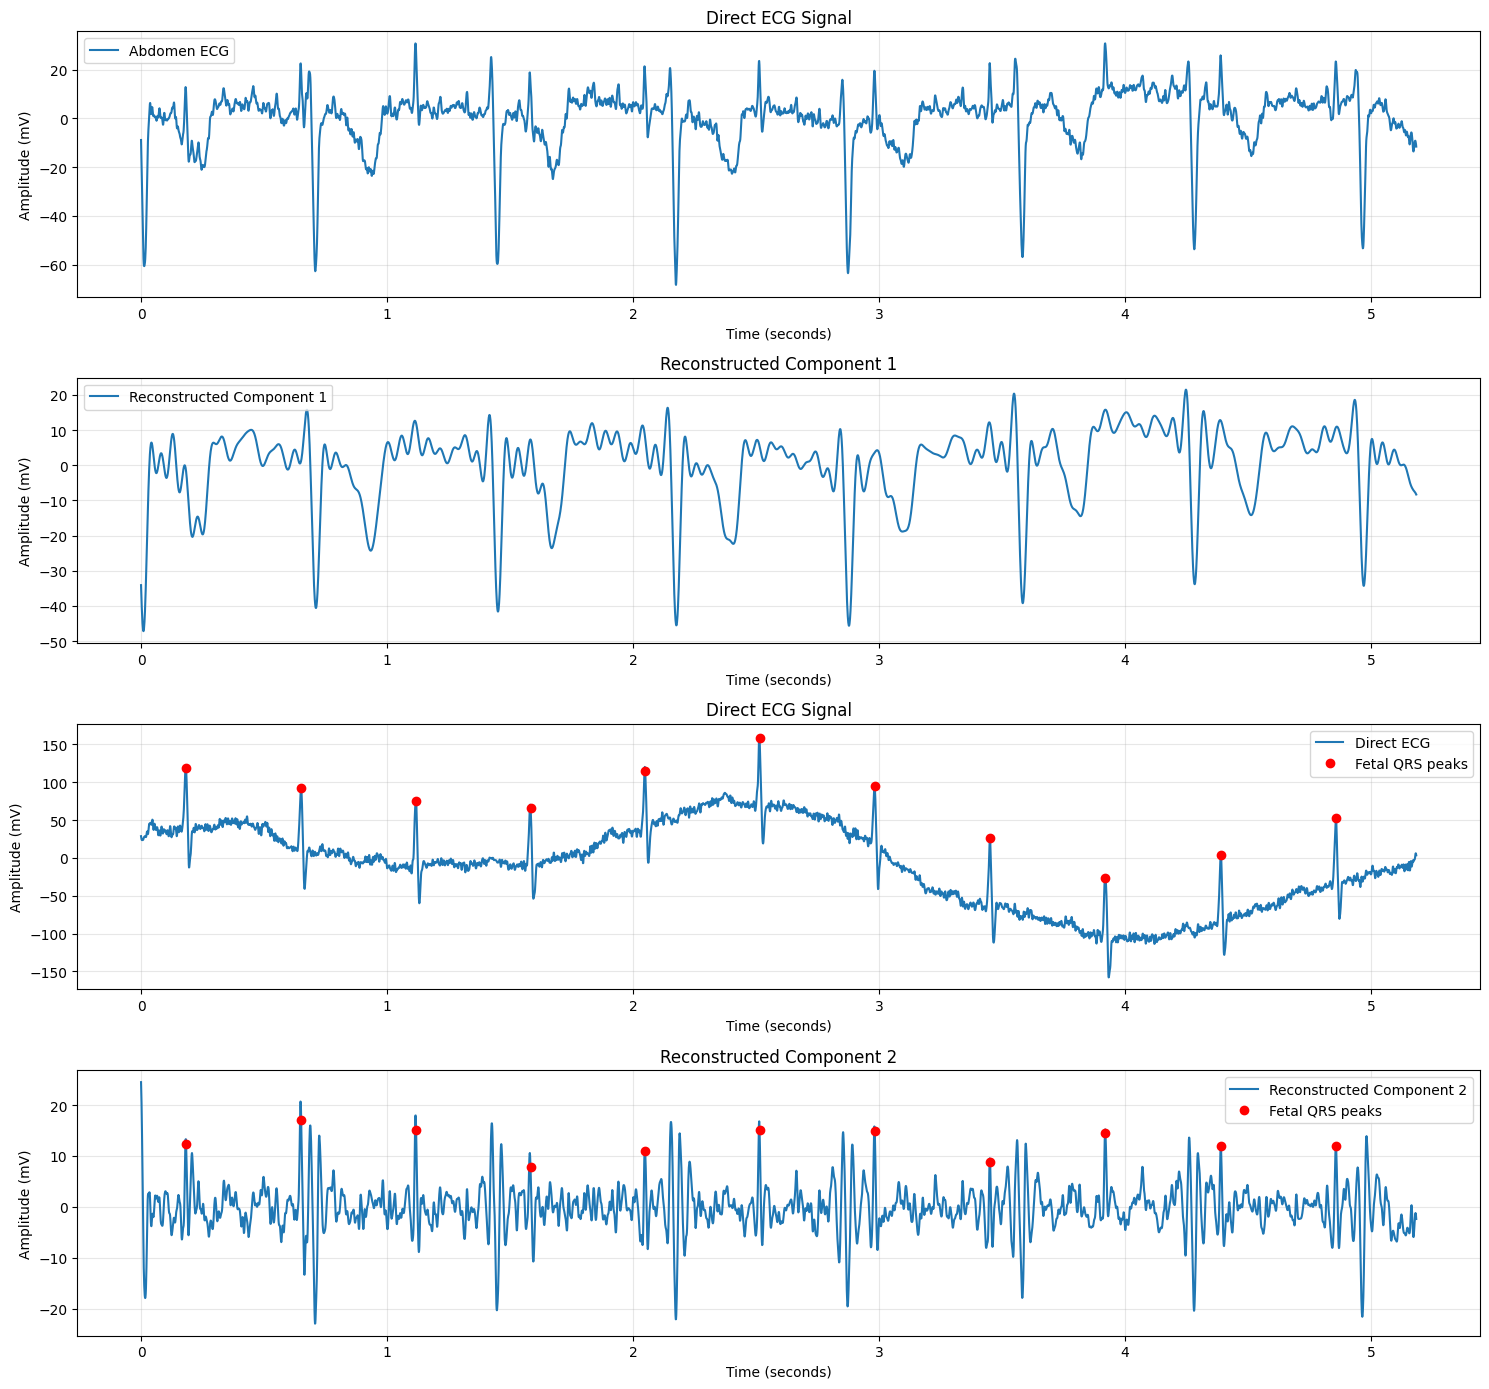

In [ ]:
# Plot original and reconstructed signals with fetal QRS peaks
plt.figure(figsize=(15, 14))

# Original Direct ECG
plt.subplot(4, 1, 1)
plt.plot(abdomen_time_segment, abdomen_signal_segment, label='Abdomen ECG')
plt.title('Direct ECG Signal')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (mV)')
plt.grid(True, alpha=0.3)
plt.legend()

# First reconstructed component
plt.subplot(4, 1, 2)
plt.plot(direct_time_segment, reconstructed_signals[0], label='Reconstructed Component 1')
plt.title('Reconstructed Component 1')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (mV)')
plt.grid(True, alpha=0.3)
plt.legend()

# Original Direct ECG
plt.subplot(4, 1, 3)
plt.plot(direct_time_segment, direct_signal_segment, label='Direct ECG')
plt.plot(onsets_in_window, direct_onset_values, 'ro', markersize=6, label="Fetal QRS peaks")
plt.title('Direct ECG Signal')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (mV)')
plt.grid(True, alpha=0.3)
plt.legend()

# Second reconstructed component with fetal QRS peaks
plt.subplot(4, 1, 4)
plt.plot(direct_time_segment, reconstructed_signals[1], label='Reconstructed Component 2')
plt.plot(onsets_in_window, np.interp(onsets_in_window, direct_time_segment, reconstructed_signals[1]),
         'ro', markersize=6, label="Fetal QRS peaks")
plt.title('Reconstructed Component 2')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (mV)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


## New Version

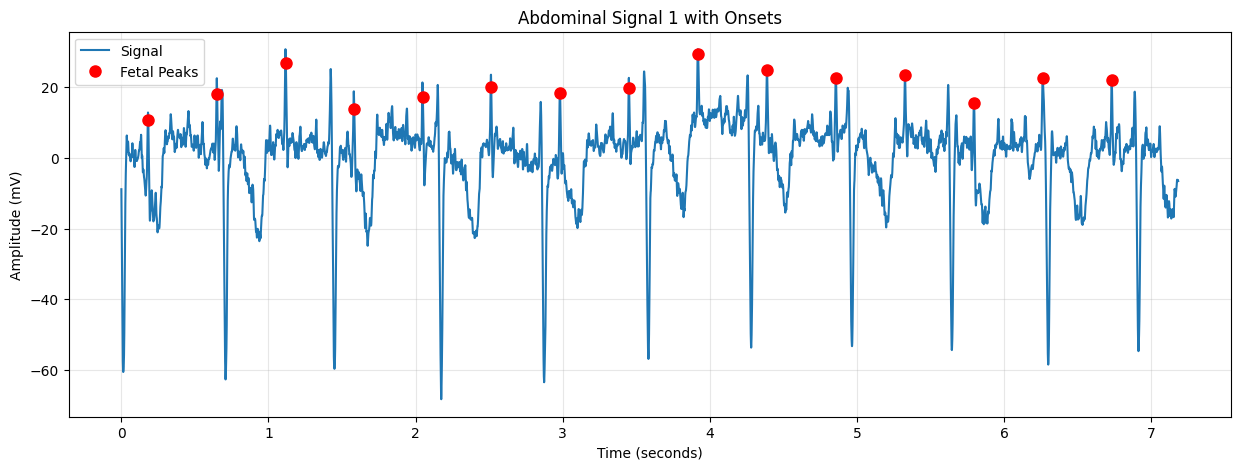

In [ ]:
plot_signal_with_onsets(abdomen_segment_1, time_segment_1, onsets_1, values_1, title="Abdominal Signal 1 with Onsets")
# This signal has 11 beats in 7 seconds for the mother and 15 beats for the fetus
# 11/7 = 1.57 -> 1/1.57 = 0.637 -> 0.637 * 1000 = 637 samples
# 15/7 = 2.14 -> 1/2.14 = 0.467 -> 0.467 * 1000 = 467 samples

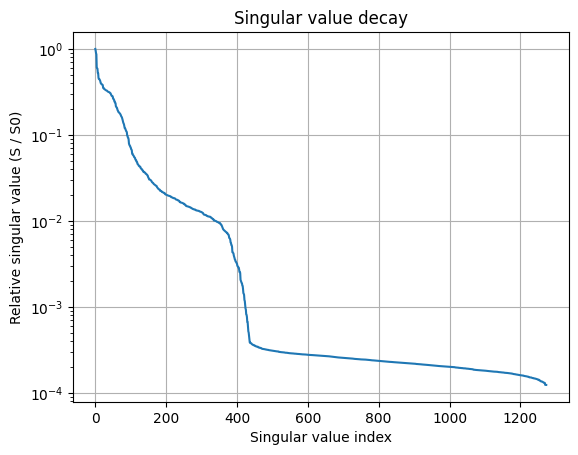

In [39]:
from scipy.linalg import hankel, svd

Lm = 637 * 2
Lf = 467 * 2
X = hankel(abdomen_segment_1[:Lm], abdomen_segment_1[Lm-1:])

U, s, Vh = svd(X, full_matrices=False)

ratio = s / s[0]
plt.semilogy(ratio)

plt.xlabel("Singular value index")
plt.ylabel("Relative singular value (S / S0)")
plt.title("Singular value decay")
plt.grid(True)
plt.show()

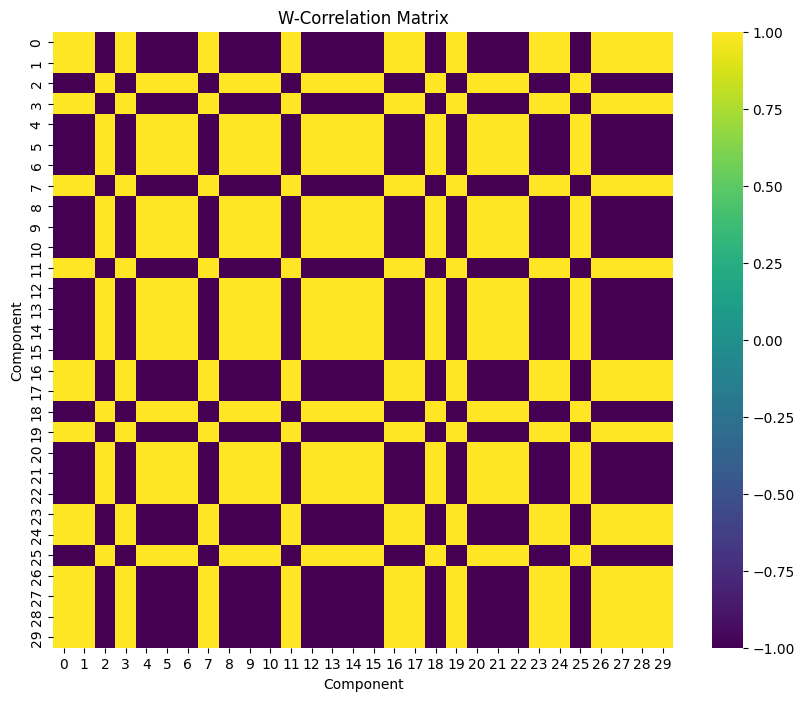

In [ ]:
import numpy as np
from scipy.linalg import svd
from matplotlib import pyplot as plt
import seaborn as sns

def w_correlation(X, U, S, V):
    N = X.shape[0] + X.shape[1] - 1
    L = X.shape[0]
    
    rc_list = []
    num_singular_values = S.shape[0]
    for i in range(num_singular_values):
        sigma_i = np.zeros_like(S)
        sigma_i[i] = S[i]
        Xi = U @ np.diag(sigma_i) @ V.T
        
        rc = np.zeros(N)
        for j in range(L):
            for k in range(L):
                if j + k == L-1:
                    rc[j+k] += Xi[j, k] / (min(j+1, k+1, N-j, N-k))
    
        rc_list.append(rc)
        
    w_corr = np.corrcoef(rc_list)
    
    return w_corr

w_corr_matrix = w_correlation(X, U[:, :30], s[:30], Vh[:, :30])

plt.figure(figsize=(10, 8))
sns.heatmap(w_corr_matrix, annot=False, cmap="viridis")
plt.title('W-Correlation Matrix')
plt.xlabel('Component')
plt.ylabel('Component')
plt.show()